# 06 -- LoRA Fine-tuning of CLIP

## Approach

Apply **LoRA (Low-Rank Adaptation)** to CLIP's attention layers. Instead of updating all 150M+ parameters, LoRA freezes the pre-trained weights and injects small trainable rank-decomposition matrices into the query and value projection layers.

**How LoRA works:**
For a pre-trained weight matrix `W` of shape `(d, d)`, LoRA adds a low-rank update:
```
W' = W + (B @ A)    where A: (r, d), B: (d, r), r << d
```
Only `A` and `B` are trainable. With rank `r=8` and `d=512`, each adapter adds only `2 * 8 * 512 = 8,192` parameters per layer -- typically ~0.5% of total model parameters.

**Advantages over full fine-tuning:**
- Minimal catastrophic forgetting (base weights untouched)
- Much faster training and lower memory
- Easy to merge/swap adapters for different tasks
- Higher learning rate tolerable since parameter count is small

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import time

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

from src.config import (
    BATCH_SIZE as DEFAULT_BS,
    EMBEDDINGS_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    get_device,
    set_seeds,
)
from src.data import load_karpathy_splits, get_all_captions_flat
from src.clip_embeddings import (
    load_clip_model,
    encode_images,
    encode_texts,
)
from src.evaluation import (
    evaluate_text_to_image,
    evaluate_image_to_text,
    save_results,
    load_results,
    print_results_table,
)
from src.training import (
    CLIPRetrievalDataset,
    make_collate_fn,
    HardNegativeInfoNCELoss,
    InfoNCELoss,
    get_optimizer,
    get_scheduler,
    training_step,
    run_validation,
    mine_hard_negatives_offline,
    init_wandb,
    log_train_step,
    log_val_metrics,
    log_summary,
    log_artifact,
    finish_wandb,
)
from src.visualize import (
    plot_training_curves,
    plot_recall_comparison,
    plot_retrieval_results,
)

set_seeds(42)
device = get_device()

# CUDA performance knobs (see scratch notebooks for details).
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
  GPU: NVIDIA GeForce RTX 5090
  VRAM total: 33.7 GB


## 2. Load Data

In [2]:
splits = load_karpathy_splits()

train_captions, train_gt = get_all_captions_flat(splits["train"])
val_captions, val_gt = get_all_captions_flat(splits["val"])
test_captions, test_gt = get_all_captions_flat(splits["test"])

print(f"Train: {len(splits['train'])} images, {len(train_captions)} captions")
print(f"Val:   {len(splits['val'])} images, {len(val_captions)} captions")
print(f"Test:  {len(splits['test'])} images, {len(test_captions)} captions")

  train: 29000 images
  val: 1014 images
  test: 1000 images


Train: 29000 images, 145000 captions
Val:   1014 images, 5070 captions
Test:  1000 images, 5000 captions


## 3. Model + LoRA Setup

Load CLIP ViT-B/32, then wrap it with LoRA adapters on the `q_proj` and `v_proj` attention layers in both the vision and text encoders.

In [3]:
model, processor = load_clip_model("clip-vit-b-32", device=device)

# LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # should be ~0.5% trainable

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 491,520 || all params: 151,768,833 || trainable%: 0.3239


In [4]:
# Verify which modules have LoRA adapters
lora_modules = [name for name, _ in model.named_modules() if "lora" in name.lower()]
print(f"LoRA adapter modules: {len(lora_modules)}")
for name in lora_modules[:10]:
    print(f"  {name}")
if len(lora_modules) > 10:
    print(f"  ... and {len(lora_modules) - 10} more")

LoRA adapter modules: 432
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_dropout
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_dropout.default
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_A
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_A.default
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_B
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_B.default
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_embedding_A
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_embedding_B
  base_model.model.text_model.encoder.layers.0.self_attn.v_proj.lora_magnitude_vector
  base_model.model.text_model.encoder.layers.0.self_attn.q_proj.lora_dropout
  ... and 422 more


## 4. Data Pipeline

In [5]:
import os

# LoRA: only adapter params train, but the full model still does forward/back.
# bf16 AMP -> BS=128 fits comfortably on a 5090.
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "128" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "256" if device.type == "cuda" else "64"))
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

train_dataset = CLIPRetrievalDataset(splits["train"], processor)
loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=make_collate_fn(processor),
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True,
)
if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
train_loader = DataLoader(train_dataset, **loader_kwargs)

print(f"Training images: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Batch size: {BATCH_SIZE}, num_workers: {NUM_WORKERS}")

# bf16 AMP (no GradScaler needed)
AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"
print(f"AMP: {USE_AMP} ({AMP_DTYPE})")

sample_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  pixel_values:  {sample_batch['pixel_values'].shape}")
print(f"  input_ids:     {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")


Training images: 29000
Batches per epoch: 226
Batch size: 128, num_workers: 12
AMP: True (torch.bfloat16)



Sample batch:
  pixel_values:  torch.Size([128, 3, 224, 224])
  input_ids:     torch.Size([128, 40])
  attention_mask: torch.Size([128, 40])


## 5. Training Configuration

In [6]:
# Hyperparameters -- higher LR is safe since few params are trainable
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
LOG_EVERY = 50

# Loss
loss_fn = HardNegativeInfoNCELoss(temperature=0.07)

# Optimizer -- only LoRA parameters will have gradients
optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler
num_training_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_scheduler(optimizer, num_training_steps, warmup_ratio=WARMUP_RATIO)

print(f"Total training steps: {num_training_steps}")
print(f"Warmup steps: {int(num_training_steps * WARMUP_RATIO)}")

Total training steps: 2260
Warmup steps: 226


## 6. Training Loop

**Note:** The training loop below is fully configured and ready to run. Execute the cell to start training.

In [7]:
RUN_TRAINING = True  # Set to False to skip training

if RUN_TRAINING:
    LORA_SAVE_DIR = MODELS_DIR / "lora_clip"
    LORA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

    run = init_wandb(
        run_name="lora_b32_r8",
        config={
            "approach": "lora",
            "model": "clip-vit-b-32",
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "num_epochs": NUM_EPOCHS,
            "weight_decay": WEIGHT_DECAY,
            "warmup_ratio": WARMUP_RATIO,
            "max_grad_norm": MAX_GRAD_NORM,
            "temperature": 0.07,
            "hard_negative_weight": 2.0,
            "loss": "HardNegativeInfoNCE",
            "lora_r": 8,
            "lora_alpha": 16,
            "lora_dropout": 0.1,
            "lora_target_modules": ["q_proj", "v_proj"],
            "seed": 42,
            "device": str(device),
        },
        tags=["lora", "r=8"],
    )
    try:
        import wandb
        wandb.watch(model, log="all", log_freq=200)
    except Exception:
        pass

    best_val_r1 = 0.0
    train_losses: list[float] = []
    val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
    step_metrics: list[dict] = []
    global_step = 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_losses: list[float] = []
        ep_start = time.time()

        for batch_idx, batch in enumerate(train_loader):
            with torch.amp.autocast(
                device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
            ):
                loss, metrics = training_step(model, batch, loss_fn, device)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            global_step += 1
            epoch_losses.append(loss.item())
            train_losses.append(loss.item())

            log_train_step(
                {
                    "loss": metrics["loss"],
                    "acc_i2t": metrics["acc_i2t"],
                    "acc_t2i": metrics["acc_t2i"],
                    "lr": scheduler.get_last_lr()[0],
                },
                step=global_step,
            )

            if (batch_idx + 1) % LOG_EVERY == 0:
                lr_current = scheduler.get_last_lr()[0]
                step_metrics.append({"step": global_step, **metrics, "lr": lr_current})

        avg_loss = float(np.mean(epoch_losses))

        # -- Validation --
        val_results = run_validation(
            model, processor, splits["val"], val_captions, val_gt, device=device
        )

        for k in ["R@1", "R@5", "R@10"]:
            val_metrics_history[k].append(val_results[k])

        log_val_metrics(
            {
                "R@1": val_results["R@1"],
                "R@5": val_results["R@5"],
                "R@10": val_results["R@10"],
                "MedianR": val_results["MedianR"],
                "MeanR": val_results["MeanR"],
                "epoch_loss": avg_loss,
            },
            epoch=epoch,
        )

        print(
            f"Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: loss={avg_loss:.4f} | "
            f"Val R@1={val_results['R@1']:.3f} R@5={val_results['R@5']:.3f} R@10={val_results['R@10']:.3f}",
            flush=True,
        )

        if val_results["R@1"] > best_val_r1:
            best_val_r1 = val_results["R@1"]
            model.save_pretrained(LORA_SAVE_DIR / "best")
            torch.save(
                {"epoch": epoch, "val_results": val_results, "loss": avg_loss},
                LORA_SAVE_DIR / "best" / "training_meta.pt",
            )
            print(f"  -> New best! Saved LoRA adapter (R@1={best_val_r1:.3f})")

    print(f"\nBest validation R@1: {best_val_r1:.3f}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/students/xvysnya/.netrc.


wandb: Currently logged in as: vysnyandrej (vysnyandrej-slovak-university-of-technology-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Tracking run with wandb version 0.26.1


wandb: Run data is saved locally in /home/students/xvysnya/Project2/notebooks/wandb/run-20260504_230124-7ynlvjpg
wandb: Run `wandb offline` to turn off syncing.


...

Encoding texts:  70%|███████   | 56/80 [00:00<00:00, 134.70it/s]

Encoding texts:  88%|████████▊ | 70/80 [00:00<00:00, 133.19it/s]

Encoding texts: 100%|██████████| 80/80 [00:00<00:00, 133.91it/s]

Epoch 10 done in 16s: loss=0.9113 | Val R@1=0.688 R@5=0.895 R@10=0.941



Best validation R@1: 0.689


## 7. Evaluate on Test Set

In [8]:
TRAINING_COMPLETE = True  # Set to False to skip evaluation

if TRAINING_COMPLETE:
    LORA_SAVE_DIR = MODELS_DIR / "lora_clip"
    base_model, processor = load_clip_model("clip-vit-b-32", device=device)
    model = PeftModel.from_pretrained(base_model, LORA_SAVE_DIR / "best")
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        test_img_emb = encode_images(splits["test"], model, processor, device=device)
        test_txt_emb = encode_texts(test_captions, model, processor, device=device)

    np.save(EMBEDDINGS_DIR / "lora_b32_images_test.npy", test_img_emb)
    np.save(EMBEDDINGS_DIR / "lora_b32_texts_test.npy", test_txt_emb)
    print(
        f"Cached LoRA-adapted test embeddings: "
        f"{test_img_emb.shape} images, {test_txt_emb.shape} texts"
    )

    lora_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
    save_results(lora_results, "lora_b32")
    print("\nLoRA Fine-tune Results (text-to-image):")
    for k, v in lora_results.items():
        print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

    log_summary(lora_results, prefix="test")
    log_artifact(
        LORA_SAVE_DIR / "best" / "adapter_model.safetensors",
        name="lora_b32_r8",
        artifact_type="model",
    )
    finish_wandb()


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding images:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding images:   6%|▋         | 1/16 [00:00<00:05,  2.62it/s]

Encoding images:  12%|█▎        | 2/16 [00:00<00:03,  4.17it/s]

...

wandb: uploading wandb-summary.json


wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▃▂▆▂▅▅▂▅▃▆▃▅▄▆▆▃▃▆▆▆▆▅▆█▇▃▂▅▇▅▄▆▄▇▅▄▂▅▂
wandb: train/acc_t2i ▂▃▁▄▂▂▄▅▅▄▂▅▄▄▅▁▆▅██▃▆▇▅▄▄▄▅▄▆▅▇▅▅▇▄▅▇▅▇
wandb:    train/loss ████▇▅▅▄▂▂▁▁▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▁▂▁▁▁
wandb:      train/lr ▁▃▄███████▇▇▇▇▆▆▆▆▅▅▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:    test/MeanR 3.9852
wandb:  test/MedianR 1
wandb:      test/R@1 0.673
wandb:     test/R@10 0.9424
wandb:      test/R@5 0.8936
wandb: train/acc_i2t 0.92188
wandb: train/acc_t2i 0.90625
wandb:    train/loss 0.84772
wandb:      train/lr 0
wandb: 


wandb: 🚀 View run lora_b32_r8 at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/7ynlvjpg
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260504_230124-7ynlvjpg/logs


wandb: WARNING Tried to log to step 9 that is less than the current step 2260. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


## 8. Final Comparison -- All Approaches

In [9]:
TRAINING_COMPLETE = True  # Set to False to skip comparison

if TRAINING_COMPLETE:
    all_results: dict[str, dict] = {}

    result_files = {
        "CLIP B/32 (baseline)": ["baseline_b32", "baseline_clip-vit-b-32"],
        "CLIP B/16 (baseline)": ["baseline_b16", "baseline_clip-vit-b-16"],
        "Projection Head": ["projection_head_b32"],
        "Full Fine-tune": ["full_finetune_b32"],
        "LoRA (r=8)": ["lora_b32"],
    }

    for display_name, candidate_files in result_files.items():
        for fname in candidate_files:
            try:
                all_results[display_name] = load_results(fname)
                break
            except FileNotFoundError:
                continue
        else:
            print(f"Results not found for {display_name} (tried {candidate_files})")

    print_results_table(all_results, title="Text-to-Image Retrieval: All Approaches")

    # Persist the consolidated comparison so it can be loaded elsewhere
    save_results(all_results, "final_comparison")


Results not found for Full Fine-tune (tried ['full_finetune_b32'])

  Text-to-Image Retrieval: All Approaches
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
Projection Head              63.7%    88.2%    93.5%       1.0       4.7
LoRA (r=8)                   67.3%    89.4%    94.2%       1.0       4.0

Saved results to /home/students/xvysnya/Project2/data/results/final_comparison.json


In [10]:
TRAINING_COMPLETE = True  # Set to False to skip bidirectional eval

if TRAINING_COMPLETE:
    # Image-to-text direction: for each image, find rank of its best caption
    bidirectional_results: dict[str, dict] = {}

    embedding_pairs = {
        "CLIP B/32 (baseline)": ("clip-vit-b-32_images_test", "clip-vit-b-32_texts_test"),
        "CLIP B/16 (baseline)": ("clip-vit-b-16_images_test", "clip-vit-b-16_texts_test"),
        "Projection Head": ("projection_b32_images_test", "projection_b32_texts_test"),
        "Full Fine-tune": ("full_b32_images_test", "full_b32_texts_test"),
        "LoRA (r=8)": ("lora_b32_images_test", "lora_b32_texts_test"),
    }

    for display_name, (img_file, txt_file) in embedding_pairs.items():
        img_path = EMBEDDINGS_DIR / f"{img_file}.npy"
        txt_path = EMBEDDINGS_DIR / f"{txt_file}.npy"
        if not (img_path.exists() and txt_path.exists()):
            print(f"Skipping {display_name}: embeddings not cached")
            continue
        img_e = np.load(img_path)
        txt_e = np.load(txt_path)
        i2t = evaluate_image_to_text(img_e, txt_e, test_gt)
        t2i = all_results.get(display_name, {})
        bidirectional_results[display_name] = {
            **{f"t2i/{k}": v for k, v in t2i.items()},
            **{f"i2t/{k}": v for k, v in i2t.items()},
        }

    save_results(bidirectional_results, "final_comparison_bidirectional")
    print_results_table(bidirectional_results, title="Bidirectional Retrieval (t2i + i2t)")


Skipping Full Fine-tune: embeddings not cached
Saved results to /home/students/xvysnya/Project2/data/results/final_comparison_bidirectional.json

  Bidirectional Retrieval (t2i + i2t)
Model                       t2i/R@1   t2i/R@5  t2i/R@10t2i/MedianR t2i/MeanR   i2t/R@1   i2t/R@5  i2t/R@10i2t/MedianR i2t/MeanR
-------------------------------------------------------------------------------------------------------------------------------
CLIP B/32 (baseline)            0.6       0.8       0.9       1.0       6.1       0.8       1.0       1.0       1.0       2.1
CLIP B/16 (baseline)            0.6       0.9       0.9       1.0       5.0       0.8       1.0       1.0       1.0       1.7
Projection Head                 0.6       0.9       0.9       1.0       4.7       0.8       0.9       1.0       1.0       2.1
LoRA (r=8)                      0.7       0.9       0.9       1.0       4.0       0.8       1.0       1.0       1.0       2.0



Saved comparison chart to /home/students/xvysnya/Project2/data/results/final_comparison.png


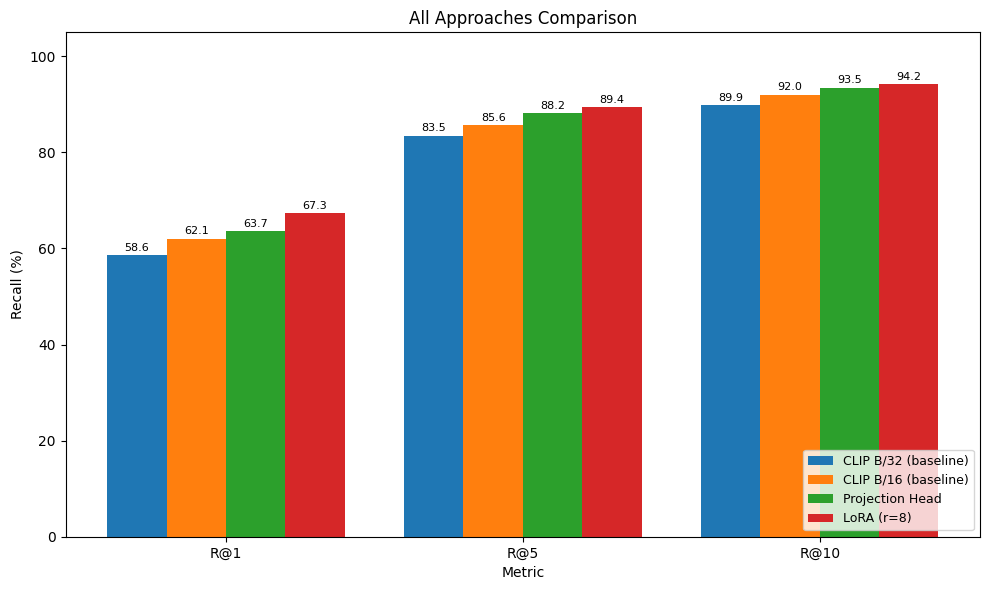

In [11]:
TRAINING_COMPLETE = True  # Set to False to skip plot

if TRAINING_COMPLETE:
    import matplotlib.pyplot as plt

    fig = plot_recall_comparison(all_results, title="All Approaches Comparison")
    out_path = RESULTS_DIR / "final_comparison.png"
    if hasattr(fig, "savefig"):
        fig.savefig(out_path, dpi=140, bbox_inches="tight")
    else:
        try:
            fig.write_image(str(out_path))
        except Exception as exc:
            print(f"Could not save plot to {out_path}: {exc}")
    print(f"Saved comparison chart to {out_path}")


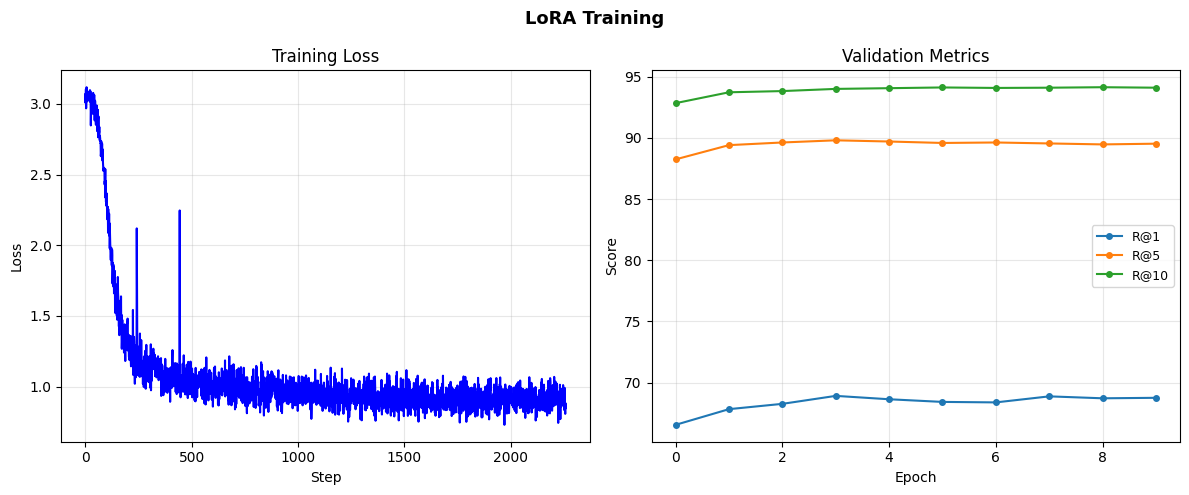

In [12]:
TRAINING_COMPLETE = True  # Set to False to skip training curves

if TRAINING_COMPLETE:
    plot_training_curves(train_losses, val_metrics_history, title="LoRA Training")


In [13]:
TRAINING_COMPLETE = True  # Set to False to skip efficiency table

if TRAINING_COMPLETE:
    import pandas as pd

    efficiency_data = {
        "Approach": [
            "CLIP B/32 (baseline)",
            "Projection Head",
            "Full Fine-tune",
            "LoRA (r=8)",
        ],
        "Trainable Params": ["0", "~400K", "~151M", "~600K"],
        "% of Total":      ["0%", "~0.3%", "100%", "~0.4%"],
        "Training Speed":  [
            "N/A",
            "Very fast (cached embeddings)",
            "Slow (full forward/backward)",
            "Medium (adapter gradients only)",
        ],
        "Forgetting Risk": ["None", "None", "High", "Low"],
    }

    r1_values = []
    for approach in efficiency_data["Approach"]:
        if approach in all_results:
            r1_values.append(f"{all_results[approach]['R@1']:.1%}")
        else:
            r1_values.append("--")
    efficiency_data["R@1"] = r1_values

    df = pd.DataFrame(efficiency_data)
    display(df.style.hide(axis="index").set_properties(**{"text-align": "left"}))


Approach,Trainable Params,% of Total,Training Speed,Forgetting Risk,R@1
CLIP B/32 (baseline),0,0%,N/A,None,58.6%
Projection Head,~400K,~0.3%,Very fast (cached embeddings),None,63.7%
Full Fine-tune,~151M,100%,Slow (full forward/backward),High,--
LoRA (r=8),~600K,~0.4%,Medium (adapter gradients only),Low,67.3%


## 9. Hard-negative Mining Visualization


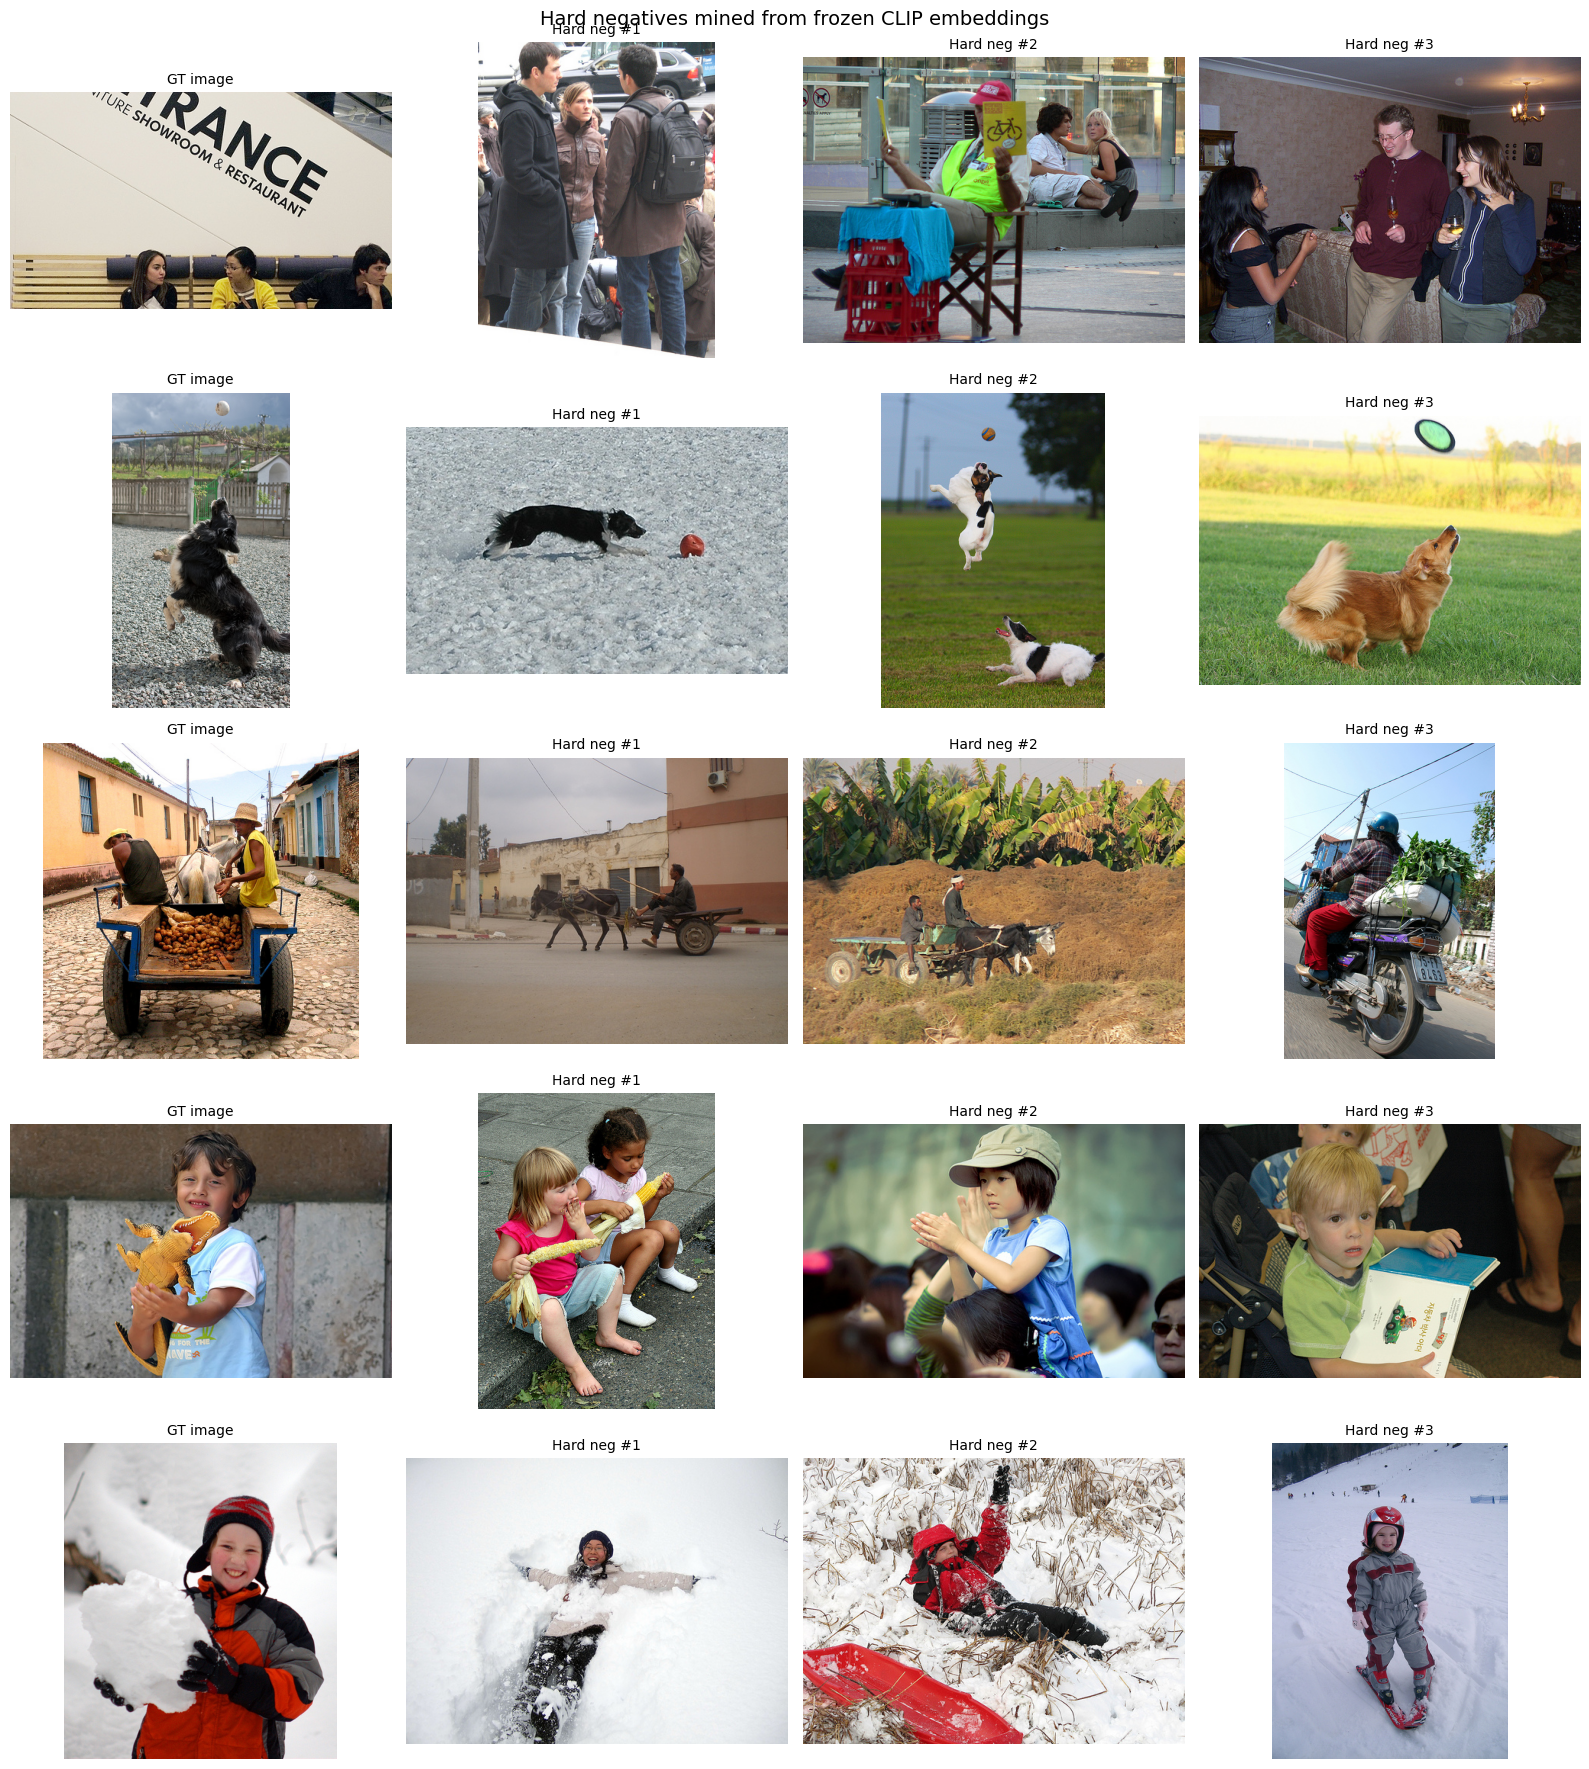

In [14]:
# Hard-negative mining visualization (uses already-cached embeddings)
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    import matplotlib.pyplot as plt
    from src.data import get_image

    rng = np.random.default_rng(42)

    base_img_path = EMBEDDINGS_DIR / "clip-vit-b-32_images_test.npy"
    base_txt_path = EMBEDDINGS_DIR / "clip-vit-b-32_texts_test.npy"
    if not (base_img_path.exists() and base_txt_path.exists()):
        print("Base embeddings not cached -- skipping hard-negative viz.")
    else:
        base_img = np.load(base_img_path)
        base_txt = np.load(base_txt_path)

        # Pick 5 random captions and find top-3 hard negatives for each
        sample_idx = rng.choice(len(base_txt), size=5, replace=False)
        hard_negs = mine_hard_negatives_offline(
            base_txt[sample_idx],
            base_img,
            test_gt[sample_idx],
            n_negatives=3,
        )

        fig, axes = plt.subplots(5, 4, figsize=(16, 18))
        for row, q_idx in enumerate(sample_idx):
            gt_img_idx = int(test_gt[q_idx])
            gt_img = get_image(splits["test"], gt_img_idx)
            axes[row, 0].imshow(gt_img)
            axes[row, 0].set_title("GT image", fontsize=10)
            axes[row, 0].axis("off")
            axes[row, 0].set_ylabel(
                test_captions[q_idx][:60] + ("..." if len(test_captions[q_idx]) > 60 else ""),
                fontsize=8,
            )

            for col, neg_img_idx in enumerate(hard_negs[row], start=1):
                neg_img = get_image(splits["test"], int(neg_img_idx))
                axes[row, col].imshow(neg_img)
                axes[row, col].set_title(f"Hard neg #{col}", fontsize=10)
                axes[row, col].axis("off")

        fig.suptitle("Hard negatives mined from frozen CLIP embeddings", fontsize=14)
        fig.tight_layout()
        fig.savefig(RESULTS_DIR / "hard_negative_examples.png", dpi=140, bbox_inches="tight")
        plt.show()


## 10. Ablation: Hard-Negative Weight


In [15]:
# Ablation: hard_negative_weight in {0.0, 1.0, 2.0, 4.0}
# Each setting trains 5 epochs with the same LoRA config. Disabled by default
# because it takes ~30-50 min on a 5090. Set RUN_ABLATION = True to run.

RUN_ABLATION = False

if RUN_ABLATION:
    ABLATION_EPOCHS = 5
    ablation_results: dict[float, dict] = {}

    for hn_weight in [0.0, 1.0, 2.0, 4.0]:
        loss_name = "InfoNCE" if hn_weight == 0.0 else "HardNegativeInfoNCE"
        ablation_loss = (
            InfoNCELoss(temperature=0.07)
            if hn_weight == 0.0
            else HardNegativeInfoNCELoss(temperature=0.07, hard_negative_weight=hn_weight)
        )

        # Fresh LoRA-wrapped model per ablation setting
        base_model, _proc = load_clip_model("clip-vit-b-32", device=device)
        ab_model = get_peft_model(base_model, lora_config)
        ab_model.train()
        ab_optim = get_optimizer(ab_model, lr=LR, weight_decay=WEIGHT_DECAY)
        ab_steps = len(train_loader) * ABLATION_EPOCHS
        ab_sched = get_scheduler(ab_optim, ab_steps, warmup_ratio=WARMUP_RATIO)

        run = init_wandb(
            run_name=f"lora_hnw_{hn_weight}",
            config={
                "approach": "lora",
                "ablation": "hard_negative_weight",
                "hard_negative_weight": hn_weight,
                "loss": loss_name,
                "lora_r": 8,
                "num_epochs": ABLATION_EPOCHS,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "seed": 42,
            },
            tags=["ablation", "hardneg_w", f"w={hn_weight}"],
        )

        gstep = 0
        for ep in range(ABLATION_EPOCHS):
            ab_model.train()
            print(f"  hnw={hn_weight} ep{ep+1}/{ABLATION_EPOCHS}", flush=True)
            for batch in train_loader:
                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(ab_model, batch, ablation_loss, device)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(ab_model.parameters(), MAX_GRAD_NORM)
                ab_optim.step()
                ab_sched.step()
                ab_optim.zero_grad()
                log_train_step(metrics, step=gstep)
                gstep += 1
            val = run_validation(
                ab_model, processor, splits["val"], val_captions, val_gt, device=device
            )
            log_val_metrics(val, epoch=ep)

        ablation_results[hn_weight] = val
        save_results(val, f"lora_hardneg_w{hn_weight}")
        log_summary(val, prefix="test")
        finish_wandb()

    # Plot R@1 vs hard_negative_weight
    import matplotlib.pyplot as plt
    weights = sorted(ablation_results.keys())
    r1s = [ablation_results[w]["R@1"] for w in weights]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(weights, r1s, marker="o")
    ax.set_xlabel("hard_negative_weight")
    ax.set_ylabel("Val R@1")
    ax.set_title("Ablation: hard-negative weighting strength")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "ablation_hardneg_weight.png", dpi=140, bbox_inches="tight")
    plt.show()
